In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/gui/data/00011
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

152


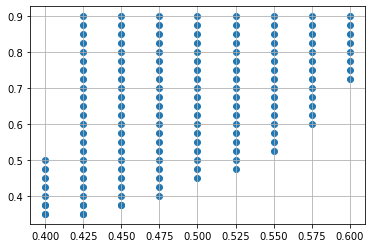

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
plt.scatter(exc, inh)

In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
dur = 100
dur_pre = 10
dur_post = 10

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[2] == '0':
    cntrl_vars_0 = [0,1]
elif case[2] == '1':
    cntrl_vars_0 = [2,3,4,5]
    
if case[3] == '0':
    maxC = [5., -5., 0.18, 0.]
elif case[3] == '1':
    maxC = [500., -500., 18., 0.]
    
if case[4] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[4] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[4] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[4] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

prec_vars = [0]
trans_time = 0.8
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [8]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'

In [9]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [10]:
i_stepsize = 7
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4000000000000001 0.3750000000000001
-------  14 0.4000000000000001 0.42500000000000016
-------  21 0.47500000000000014 0.4500000000000002
-------  28 0.5250000000000001 0.4750000000000002
-------  35 0.4250000000000001 0.5250000000000002
-------  42 0.4500000000000001 0.5500000000000003
-------  49 0.47500000000000014 0.5750000000000003
-------  56 0.5000000000000002 0.6000000000000003
-------  63 0.5000000000000002 0.6250000000000003
-------  70 0.5000000000000002 0.6500000000000004
-------  77 0.5000000000000002 0.6750000000000004
-------  84 0.5000000000000002 0.7000000000000004
-------  91 0.5000000000000002 0.7250000000000004
-------  98 0.47500000000000014 0.7500000000000004
-------  105 0.4500000000000001 0.7750000000000005
-------  112 0.4250000000000001 0.8000000000000005
-------  119 0.6000000000000003 0.8000000000000005
-------  126 0.5750000000000002 0.8250000000000005
-------  133 0.5500000000000003 0.8500000000

In [11]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140 147]


In [12]:
factor_iteration = 20.

data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i])
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    weights_init[i] = cost.getParams()

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]
    
##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  1217.1004646667843
RUN  2 , total integrated cost =  145.54265181675115
RUN  3 , total integrated cost =  81.18076627177815
RUN  4 , total integrated cost =  57.89040775735947
RUN  5 , total integrated cost =  47.246167878868285
RUN  6 , total integrated cost =  37.964471287131595
RUN  7 , total integrated cost =  30.77362490051481
RUN  8 , total integrated cost =  21.662904899750878
RUN  9 , total integrated cost =  20.603745953979608
RUN  10 , total integrated cost =  19.57246499260319
RUN  

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  47 , total integrated cost =  13.364006991165937
Improved over  47  iterations in  12.86316628754139  seconds by  99.77358375709682  percent.
Problem in initial value trasfer:  Vmean_exc -56.627620609847234 -56.62762055099662
weight =  4416.644261814645
set cost params:  1.0 0.0 4416.644261814645
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5873.038102885881
Gradient descend method:  None
RUN  1 , total integrated cost =  5069.690736000906
RUN  2 , total integrated cost =  5068.007241587993
RUN  3 , total integrated cost =  5066.974565799634
RUN  4 , total integrated cost =  5026.069066718552
RUN  5 , total integrated cost =  5024.404141392098
RUN  6 , total integrated cost =  5024.3685680614835
RUN  7 , total integrated cost =  5024.361606003612
RUN  8 , total integrated cost =  5024.359586832437
RUN  9 , total integrated cost =  5024.358710810786
RUN  10 , total integrated cost =  5024.358348125489
RUN  11 , total integ

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  22 , total integrated cost =  5024.3579154489125
Improved over  22  iterations in  0.8974185101687908  seconds by  14.45044579261193  percent.
Problem in initial value trasfer:  Vmean_exc -56.62596343265864 -56.62596386841035
-------  7 0.4000000000000001 0.3750000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5538.707762167343
Gradient descend method:  None
RUN  0 , total integrated cost =  5538.707762167343
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5538.707762167343
Gradient descend method:  None
RUN  1 , total integrated cost =  666.7946245402984
RUN  2 , total integrated cost =  66.13437158301703
RUN  3 , total integrated cost =  53.531920006140645
RUN  4 , total integrated cost =  42.922410132363126
RUN  5 , total integrated cost =  34.79525947834128
RUN  6

...

RUN  1 , total integrated cost =  19755.4958870387
Control only changes marginally.
RUN  1 , total integrated cost =  19755.4958870387
Improved over  1  iterations in  0.05718151852488518  seconds by  0.0  percent.
-------  91 0.5000000000000002 0.7250000000000004
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19611.738754959944
Gradient descend method:  None
RUN  0 , total integrated cost =  19611.738754959944
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19611.738754959944
Gradient descend method:  None
RUN  1 , total integrated cost =  19611.738754959944
Control only changes marginally.
RUN  1 , total integrated cost =  19611.738754959944
Improved over  1  iterations in  0.056645236909389496  seconds by  0.0  percent.
weight =  10.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , 

ERROR:root:Problem in initial value trasfer


RUN  50 , total integrated cost =  70.77511868111397
Control only changes marginally.
RUN  53 , total integrated cost =  70.77511868111394
Improved over  53  iterations in  1.197588924318552  seconds by  99.81838035863947  percent.
Problem in initial value trasfer:  Vmean_exc -56.699987732387115 -56.69998771484537
weight =  5506.012414235303
set cost params:  1.0 0.0 5506.012414235303
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38432.56832113042
Gradient descend method:  None
RUN  1 , total integrated cost =  35603.78937448805
RUN  2 , total integrated cost =  35595.850867601104
RUN  3 , total integrated cost =  35482.07153845144
RUN  4 , total integrated cost =  35436.66117762883
RUN  5 , total integrated cost =  35435.29630376923
RUN  6 , total integrated cost =  35434.469356972724
RUN  7 , total integrated cost =  35430.07838860433
RUN  8 , total integrated cost =  35346.88784442687
RUN  9 , total integrated cost =  35322.40370479639
RUN  10 , total integ

ERROR:root:Problem in initial value trasfer


RUN  20 , total integrated cost =  35322.114956521415
Control only changes marginally.
RUN  20 , total integrated cost =  35322.114956521415
Improved over  20  iterations in  0.5298910345882177  seconds by  8.093274793969101  percent.
Problem in initial value trasfer:  Vmean_exc -56.699991026964526 -56.69999085679006
-------  126 0.5750000000000002 0.8250000000000005
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33632.4581250047
Gradient descend method:  None
RUN  0 , total integrated cost =  33632.4581250047
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33632.4581250047
Gradient descend method:  None
RUN  1 , total integrated cost =  33632.4581250047
Control only changes marginally.
RUN  1 , total integrated cost =  33632.4581250047
Improved over  1  iterations in  0.10789772495627403  seconds by  0.0  percent.

/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


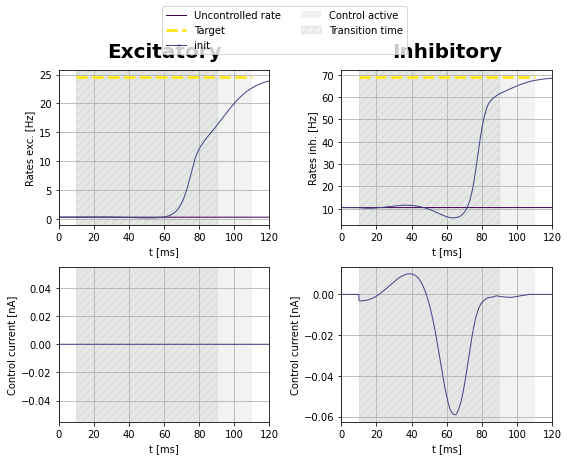

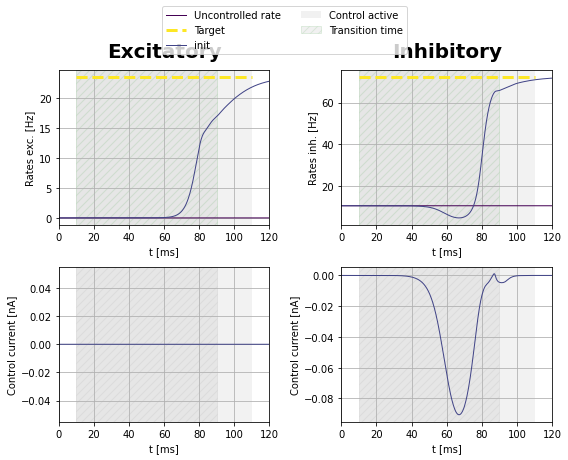

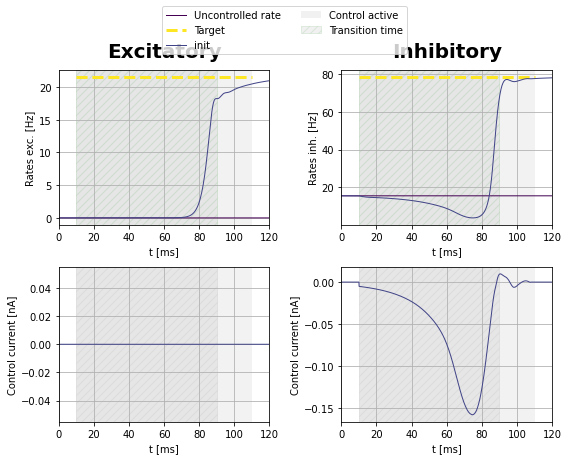

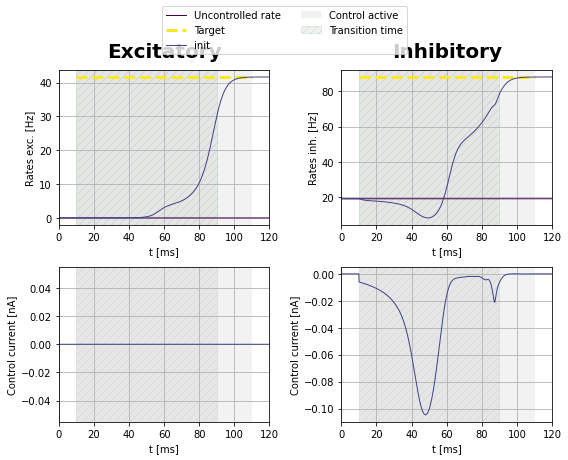

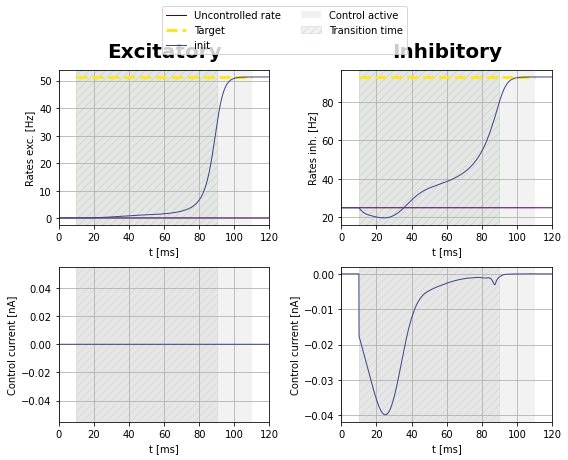

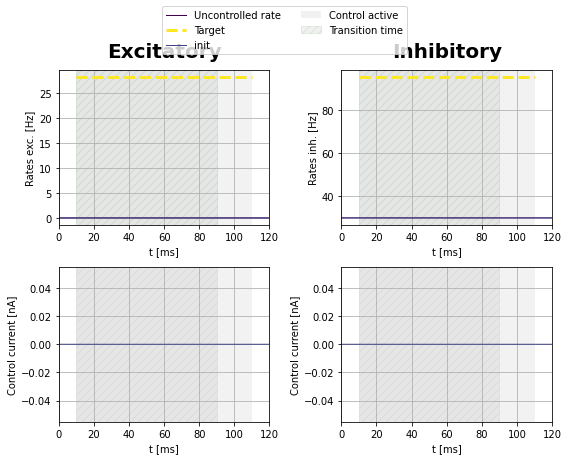

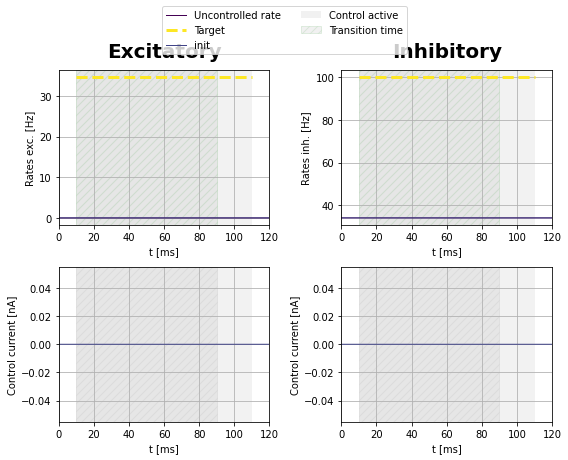

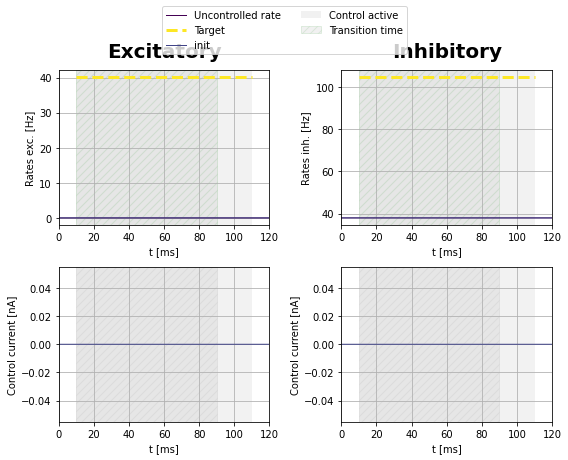

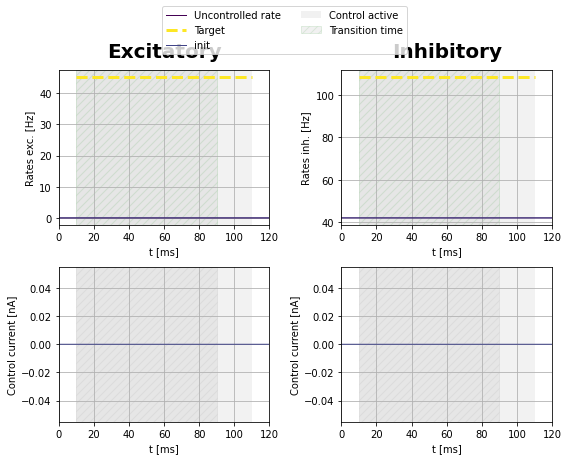

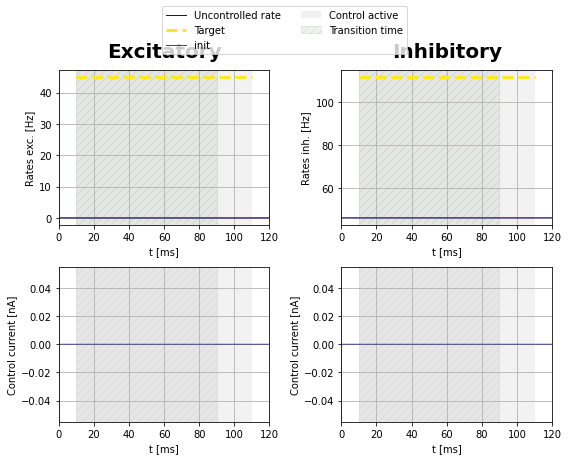

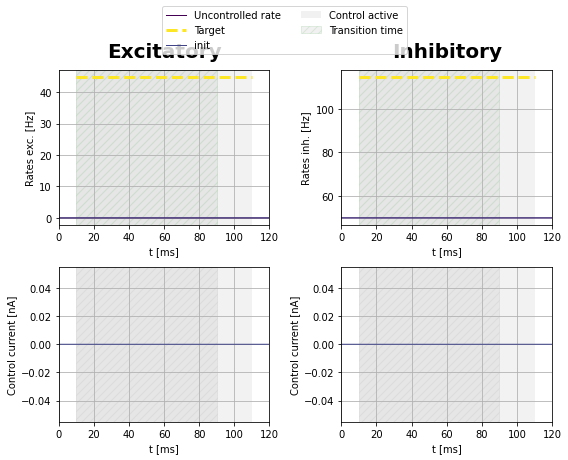

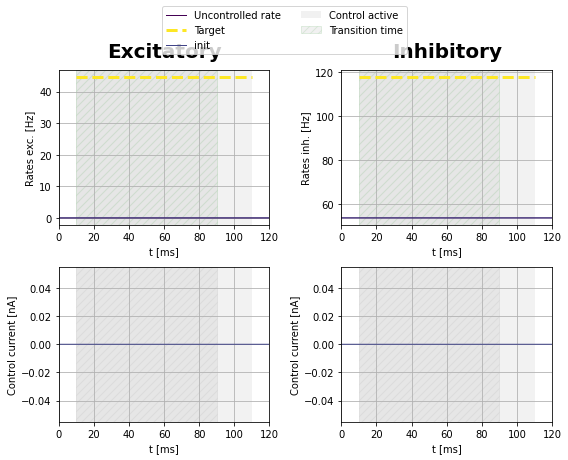

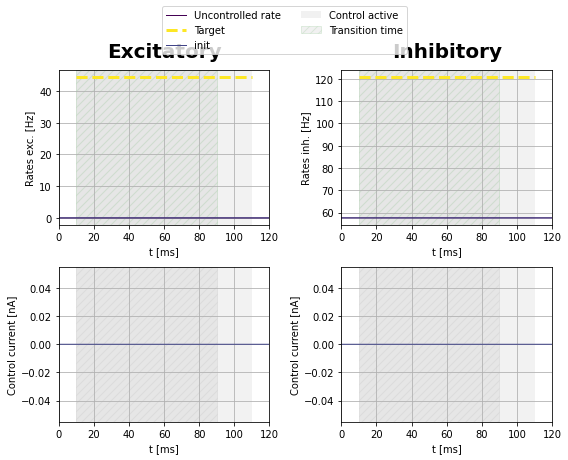

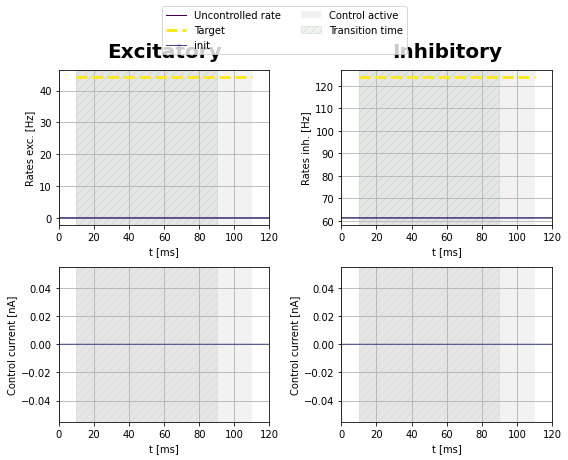

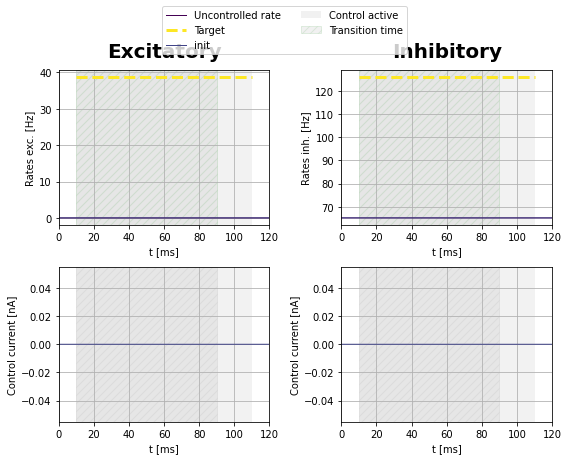

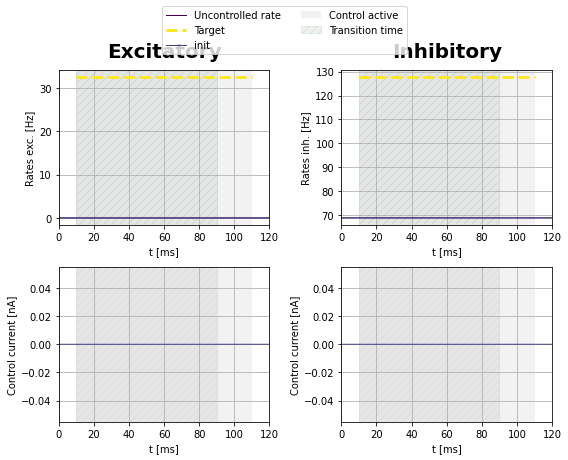

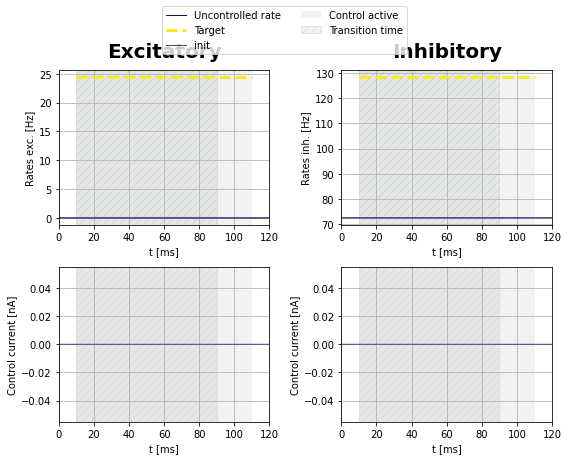

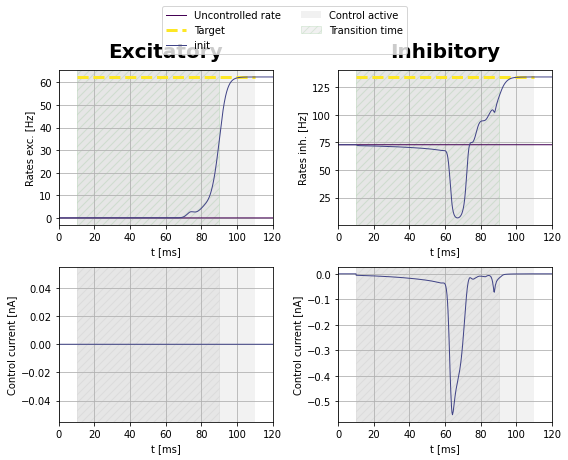

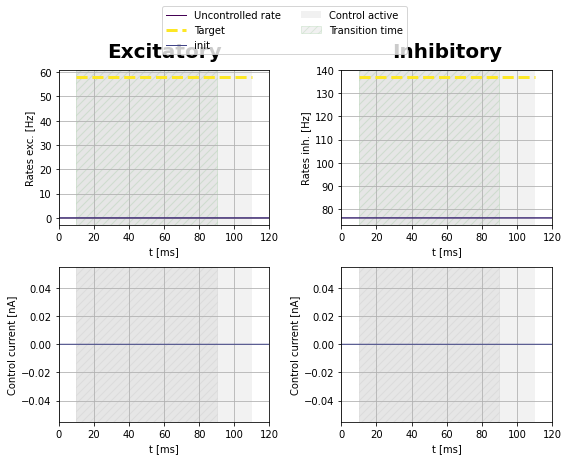

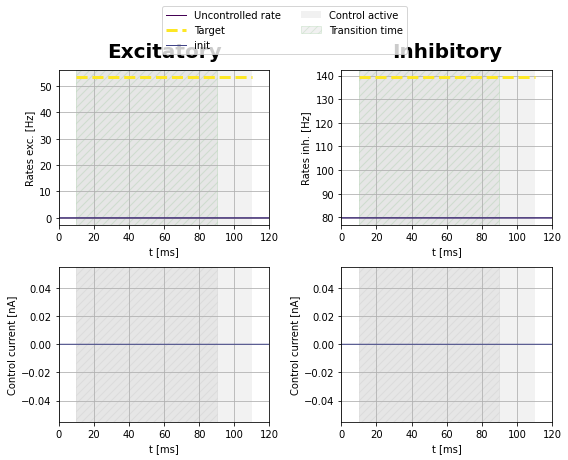

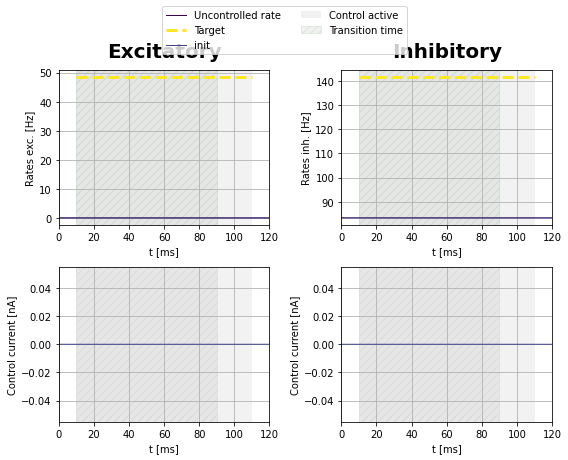

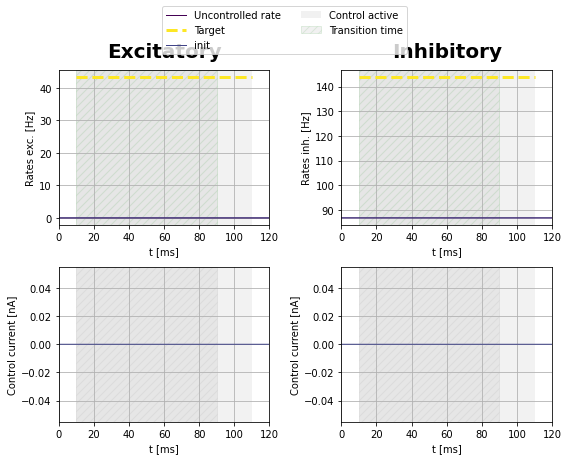

In [13]:
#plot initial guesses

for i in i_range:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [14]:
for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
        
    if np.abs(cost_uncontrolled[i] - costnode_init[i][0][0][0]) > 1.:
        continue
        
    print("no solution found for ", i)
    
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    if i != 0:
        control0 = bestControl_init[i-2*i_stepsize][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4000000000000001 0.3750000000000001
-------  14 0.4000000000000001 0.42500000000000016
-------  21 0.47500000000000014 0.4500000000000002
-------  28 0.5250000000000001 0.4750000000000002
-------  35 0.4250000000000001 0.5250000000000002
no solution found for  35
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7997.482868054778
Gradient descend method:  None
RUN  1 , total integrated cost =  7978.733668940681
RUN  2 , total integrated cost =  7978.340142513285
RUN  3 , total integrated cost =  7978.318635406878
RUN  4 , total integrated cost =  7978.317254025261
RUN  5 , total integrated cost =  7978.317182498783
RUN  6 , total integrated cost =  7978.317181817648
RUN  7 , total integrated cost =  7978.317181785728
RUN  8 , total integrated cost =  7978.317181785683
RUN  9 , total integrated cost =  7978.317181785681
RUN  10 , total integrated cost =  7978.317181785681
C

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  27 , total integrated cost =  59.4608229245405
Improved over  27  iterations in  1.0643579699099064  seconds by  99.2547197413975  percent.
Problem in initial value trasfer:  Vmean_exc -56.637916697842854 -56.63791636126837
-------  42 0.4500000000000001 0.5500000000000003
no solution found for  42
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  12025.964256100846
Gradient descend method:  None
RUN  1 , total integrated cost =  12017.595011175466
RUN  2 , total integrated cost =  62.4279563837485
RUN  3 , total integrated cost =  58.75313225346198
RUN  4 , total integrated cost =  58.74270672330713
RUN  5 , total integrated cost =  58.73968129439286
RUN  6 , total integrated cost =  58.73234533171738
RUN  7 , total integrated cost =  58.71827248655115
RUN  8 , total integrated cost =  58.716412721040356
RUN  9 , total integrated cost =  58.69054782445656
RUN  10 , total integrated cost =  58.66

ERROR:root:Problem in initial value trasfer


RUN  50 , total integrated cost =  57.86485863854548
Control only changes marginally.
RUN  50 , total integrated cost =  57.86485863854548
Improved over  50  iterations in  1.852239491418004  seconds by  99.51883393791736  percent.
Problem in initial value trasfer:  Vmean_exc -56.66480520241661 -56.6648049525695
weight =  2076.818848321529
set cost params:  1.0 0.0 2076.818848321529
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  12008.264037175626
Gradient descend method:  None
RUN  1 , total integrated cost =  11968.256866825868
RUN  2 , total integrated cost =  11966.595315193757
RUN  3 , total integrated cost =  11964.289264665102
RUN  4 , total integrated cost =  11964.264340786465
RUN  5 , total integrated cost =  11964.26222501445
RUN  6 , total integrated cost =  11964.261609793119
RUN  7 , total integrated cost =  11964.261322518047
RUN  8 , total integrated cost =  11964.261132324196
RUN  9 , total integrated cost =  11964.260955608068
RUN  10 , total 

...

Control only changes marginally.
RUN  26 , total integrated cost =  26636.48360247278
Improved over  26  iterations in  0.9366854559630156  seconds by  5.374063730750564  percent.
Problem in initial value trasfer:  Vmean_exc -56.70401458517559 -56.704014652392814
-------  140 0.5250000000000001 0.8750000000000006
no solution found for  140
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23532.636143093983
Gradient descend method:  None
RUN  1 , total integrated cost =  23532.636143093983
Control only changes marginally.
RUN  1 , total integrated cost =  23532.636143093983
Improved over  1  iterations in  0.06880997121334076  seconds by  0.0  percent.
weight =  10.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23532.636143093983
Gradient descend method:  None
RUN  1 , total integrated cost =  23532.636143093983
Control only changes marginally.
RUN  1 , total integrated cost =

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  22 , total integrated cost =  140.1852026022974
Improved over  22  iterations in  0.5017212089151144  seconds by  99.25818567632203  percent.
Problem in initial value trasfer:  Vmean_exc -56.692006455485945 -56.69200630765484
weight =  1341.0683499970994
set cost params:  1.0 0.0 1341.0683499970994
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18670.866650013857
Gradient descend method:  None
RUN  1 , total integrated cost =  18040.116007464945
RUN  2 , total integrated cost =  18036.299347141947
RUN  3 , total integrated cost =  18032.71088078939
RUN  4 , total integrated cost =  18009.34901955874
RUN  5 , total integrated cost =  18000.373514767183
RUN  6 , total integrated cost =  17999.39212666081
RUN  7 , total integrated cost =  17987.961020239247
RUN  8 , total integrated cost =  17965.802413966736
RUN  9 , total integrated cost =  17964.311415514312
RUN  10 , total integrated cost =  17964.013681552304
RUN  11 , to

ERROR:root:Problem in initial value trasfer


RUN  17 , total integrated cost =  17898.437954568348
RUN  18 , total integrated cost =  17898.437954387766
RUN  19 , total integrated cost =  17898.43795438577
RUN  20 , total integrated cost =  17898.437954385645
Control only changes marginally.
RUN  22 , total integrated cost =  17898.437954385638
Improved over  22  iterations in  0.5511724520474672  seconds by  4.13708003012087  percent.
Problem in initial value trasfer:  Vmean_exc -56.69189281438683 -56.69189604684816


In [15]:
for k in range(20):

    factor_iteration = 20

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i])
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
weight =  5187.489782399709
set cost params:  1.0 0.0 5187.489782399709
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5855.6162417789765
Gradient descend method:  None
RUN  1 , total integrated cost =  5853.626174270826
RUN  2 , total integrated cost =  5853.571818061239
RUN  3 , total integrated cost =  5853.563660208321
RUN  4 , total integrated cost =  5853.5615104375665
RUN  5 , total integrated cost =  5853.560870870588
RUN  6 , total integrated cost =  5853.560656564933
RUN  7 , total integrated cost =  5853.560557048819
RUN  8 , total integrated cost =  5853.560515661002
RUN  9 , total integrated cost =  5853.5604988135965
RUN  10 , total integrated cost =  5853.560491156488
RUN  11 , total integrated cost =  5853.560488248273
RUN  12 , total integrated cost =  5853.560486909297
RUN  13 , total integrated cost =  5853.560486236649
RUN  14 , total integrated cost =  5853.5604859011055
RUN  15 , total integ

ERROR:root:Problem in initial value trasfer


RUN  30 , total integrated cost =  5853.560485563135
Control only changes marginally.
RUN  32 , total integrated cost =  5853.5604855631345
Improved over  32  iterations in  1.115321645513177  seconds by  0.03510742731353389  percent.
Problem in initial value trasfer:  Vmean_exc -56.62602349904506 -56.62600093381703
-------  7 0.4000000000000001 0.3750000000000001
weight =  3143.3484227883846
set cost params:  1.0 0.0 3143.3484227883846
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5524.021853967326
Gradient descend method:  None
RUN  1 , total integrated cost =  5523.714881616299
RUN  2 , total integrated cost =  5523.702473460461
RUN  3 , total integrated cost =  5523.701528125703
RUN  4 , total integrated cost =  5523.701443882364
RUN  5 , total integrated cost =  5523.701435388524
RUN  6 , total integrated cost =  5523.701433546146
RUN  7 , total integrated cost =  5523.701433212963
RUN  8 , total integrated cost =  5523.701433144659
RUN  9 , total integra

ERROR:root:Problem in initial value trasfer


RUN  15 , total integrated cost =  5523.701433128301
RUN  16 , total integrated cost =  5523.701433128301
Control only changes marginally.
RUN  16 , total integrated cost =  5523.701433128301
Improved over  16  iterations in  0.3961894605308771  seconds by  0.005800499119942515  percent.
Problem in initial value trasfer:  Vmean_exc -56.625847806144 -56.625831537857444
-------  14 0.4000000000000001 0.42500000000000016
weight =  1384.162486203351
set cost params:  1.0 0.0 1384.162486203351
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4638.271004694887
Gradient descend method:  None
RUN  1 , total integrated cost =  4638.267983552863
RUN  2 , total integrated cost =  4638.26754646431
RUN  3 , total integrated cost =  4638.267468331605
RUN  4 , total integrated cost =  4638.267459596137
RUN  5 , total integrated cost =  4638.2674584166425
RUN  6 , total integrated cost =  4638.267458276758
RUN  7 , total integrated cost =  4638.267458256286
RUN  8 , total integr

...

RUN  1 , total integrated cost =  5980.268875850367
Control only changes marginally.
RUN  1 , total integrated cost =  5980.268875850367
Improved over  1  iterations in  0.041688865050673485  seconds by  0.0  percent.
-------  119 0.6000000000000003 0.8000000000000005
weight =  6084.099190010636
set cost params:  1.0 0.0 6084.099190010636
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38962.4642253038
Gradient descend method:  None
RUN  1 , total integrated cost =  38962.4642253038
Control only changes marginally.
RUN  1 , total integrated cost =  38962.4642253038
Improved over  1  iterations in  0.07278000004589558  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.69999135843146 -56.69999117233663
-------  126 0.5750000000000002 0.8250000000000005
weight =  173.9545798908656
set cost params:  1.0 0.0 173.9545798908656
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33440.22275656802
Gradient descend method:  No

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  33440.22275656802
Control only changes marginally.
RUN  1 , total integrated cost =  33440.22275656802
Improved over  1  iterations in  0.12656761147081852  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.703833652165756 -56.70384029862035
-------  133 0.5500000000000003 0.8500000000000005
weight =  2880.88684530114
set cost params:  1.0 0.0 2880.88684530114
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  28466.95911516339
Gradient descend method:  None
RUN  1 , total integrated cost =  28466.95911516339
Control only changes marginally.
RUN  1 , total integrated cost =  28466.95911516339
Improved over  1  iterations in  0.08005385100841522  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70401447173611 -56.70401454355762
-------  140 0.5250000000000001 0.8750000000000006
weight =  188.44452406618763
set cost params:  1.0 0.0 188.44452406618763
interpolate adjoint :  True True

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  23408.417001584927
Control only changes marginally.
RUN  1 , total integrated cost =  23408.417001584927
Improved over  1  iterations in  0.18775752559304237  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.700801623474206 -56.70081485579882
-------  147 0.5000000000000002 0.9000000000000006
weight =  1408.295654270991
set cost params:  1.0 0.0 1408.295654270991
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18786.45398393489
Gradient descend method:  None
RUN  1 , total integrated cost =  18786.45398393489
Control only changes marginally.
RUN  1 , total integrated cost =  18786.45398393489
Improved over  1  iterations in  0.0722767785191536  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.691888974349894 -56.691892319461616


In [16]:
with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

In [17]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [18]:
factor_iteration = 20
    
for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i])
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  319.16442475079845
Gradient descend method:  None
RUN  1 , total integrated cost =  13.46219001281878
RUN  2 , total integrated cost =  13.381872165020559
RUN  3 , total integrated cost =  13.373593531844353
RUN  4 , total integrated cost =  13.354255720891993
RUN  5 , total integrated cost =  13.339112221729879
RUN  6 , total integrated cost =  13.331291196861907
RUN  7 , total integrated cost =  13.327112438638151
RUN  8 , total integrated cost =  13.31193968368826
RUN  9 , total integrated cost =  13.301215418133417
RUN  10 , total integrated cost =  13.298478089552702
RUN  11 , total integrated cost =  13.292482502136918
RUN  12 , total integrated cost =  13.28934779624163
RUN  13 , total integrated cost =  13.271197782132981
RUN  14 , total integrated cost =  13.259935995840321
RUN  15 , total integrated cost =  13.247960077450438


ERROR:root:Problem in initial value trasfer


State only changes marginally.
Control only changes marginally.
RUN  65 , total integrated cost =  13.105429156403307
Improved over  65  iterations in  5.745891880244017  seconds by  95.89383147365626  percent.
Problem in initial value trasfer:  Vmean_exc -56.627616003044785 -56.62761609890341
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  130.6087939457714
Gradient descend method:  HS
RUN  1 , total integrated cost =  129.087474208193
RUN  2 , total integrated cost =  128.0988596000323
RUN  3 , total integrated cost =  127.94207414017215
RUN  4 , total integrated cost =  127.92352026718977
RUN  5 , total integrated cost =  127.81212467614283
RUN  6 , total integrated cost =  126.6756995814083
RUN  7 , total integrated cost =  126.59035924295404
RUN  8 , total integrated cost =  126.53309121167621
RUN  9 , total integrated cost =  126.51408417550861
RUN  10 , total integrated cost =  126.40166953661421
RUN  11 , tot

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  45 , total integrated cost =  115.59877355410116
Improved over  45  iterations in  3.8428419679403305  seconds by  11.49235050581845  percent.
Problem in initial value trasfer:  Vmean_exc -56.62759358195955 -56.62759359786476
weight =  5104.942128768355
set cost params:  1.0 0.0 5104.942128768355
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5816.332035420402
Gradient descend method:  None
RUN  1 , total integrated cost =  5365.021234571675
RUN  2 , total integrated cost =  5352.092694755845
RUN  3 , total integrated cost =  5344.875063815384
RUN  4 , total integrated cost =  5326.020105524631
RUN  5 , total integrated cost =  5325.718006273061
RUN  6 , total integrated cost =  5325.597812628723
RUN  7 , total integrated cost =  5325.535128007826
RUN  8 , total integrated cost =  5325.502161532474
RUN  9 , total integrated cost =  5325.482531016304
RUN  10 , total integrated cost =  5325.4722000741895
RUN  11 , total integ

...

RUN  1000 , total integrated cost =  131.79326628494184
RUN  1000 , total integrated cost =  131.79326628494184
Improved over  1000  iterations in  64.20683271996677  seconds by  59.08232371329387  percent.
Problem in initial value trasfer:  Vmean_exc -56.69199680546422 -56.69199712349536
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1317.5715921644046
Gradient descend method:  HS
RUN  1 , total integrated cost =  1316.4123723482035
RUN  2 , total integrated cost =  1312.0348623287389
RUN  3 , total integrated cost =  1311.8099808905747
RUN  4 , total integrated cost =  1311.5927544721164
RUN  5 , total integrated cost =  1311.495085560595
RUN  6 , total integrated cost =  1311.4054497905365
RUN  7 , total integrated cost =  1311.212481979339
RUN  8 , total integrated cost =  1311.2124819793387
RUN  9 , total integrated cost =  1311.1309338717335
RUN  10 , total integrated cost =  1309.4835964671463
RUN  11 , total

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  272 , total integrated cost =  1267.2642886722872
Improved over  272  iterations in  21.81598074361682  seconds by  3.8181836790725328  percent.
Problem in initial value trasfer:  Vmean_exc -56.69200419096328 -56.69200414613776
weight =  1482.494327334336
set cost params:  1.0 0.0 1482.494327334336
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18772.338396346335
Gradient descend method:  None
RUN  1 , total integrated cost =  18711.877145242728
RUN  2 , total integrated cost =  18665.622566904778
RUN  3 , total integrated cost =  18641.141993709436
RUN  4 , total integrated cost =  18639.828080293963
RUN  5 , total integrated cost =  18639.822700140452
RUN  6 , total integrated cost =  18639.822678893615
RUN  7 , total integrated cost =  18639.82267860765
RUN  8 , total integrated cost =  18639.82267860444
RUN  9 , total integrated cost =  18639.822678604425
RUN  10 , total integrated cost =  18639.82267860442


ERROR:root:Problem in initial value trasfer


RUN  11 , total integrated cost =  18639.82267860442
Control only changes marginally.
RUN  11 , total integrated cost =  18639.82267860442
Improved over  11  iterations in  0.932215103879571  seconds by  0.7059094873748109  percent.
Problem in initial value trasfer:  Vmean_exc -56.692118473325 -56.69211394420516


/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


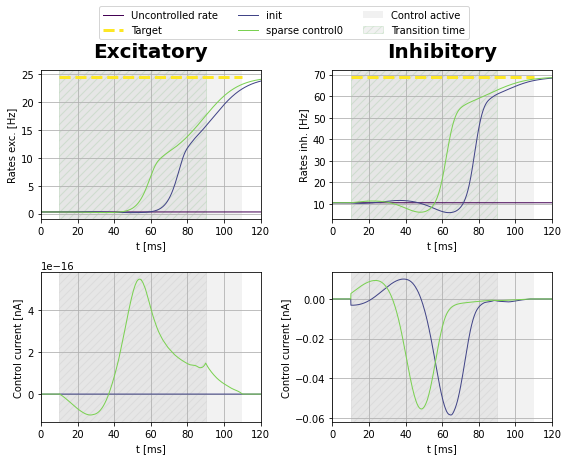

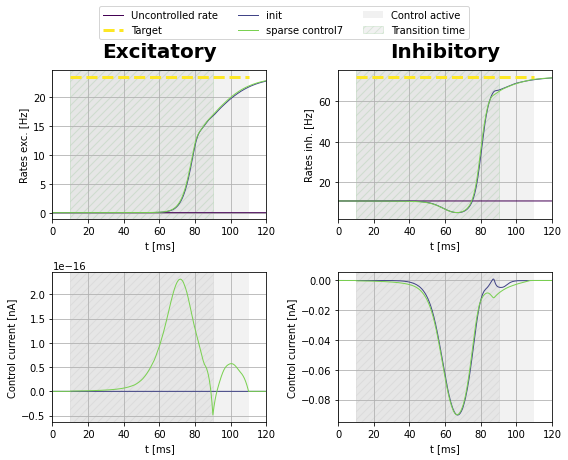

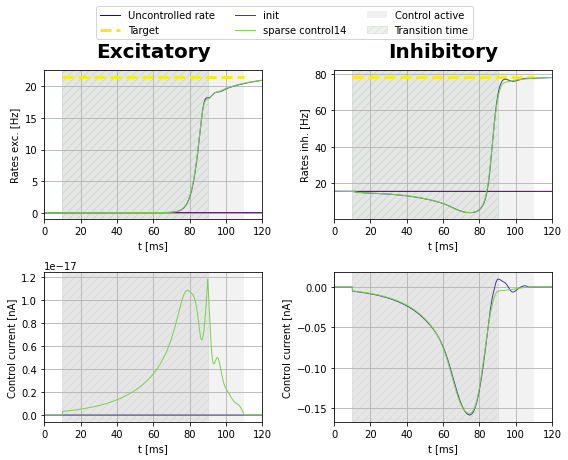

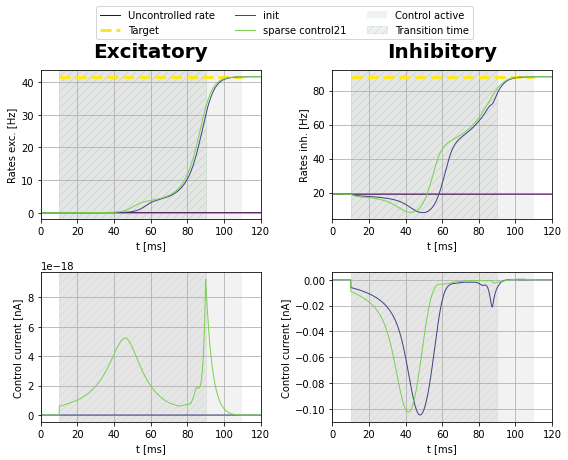

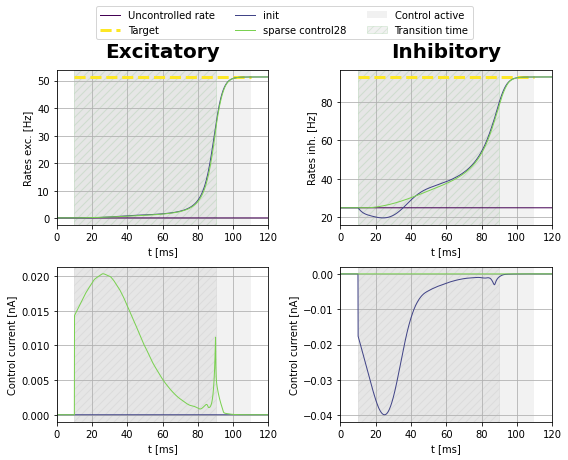

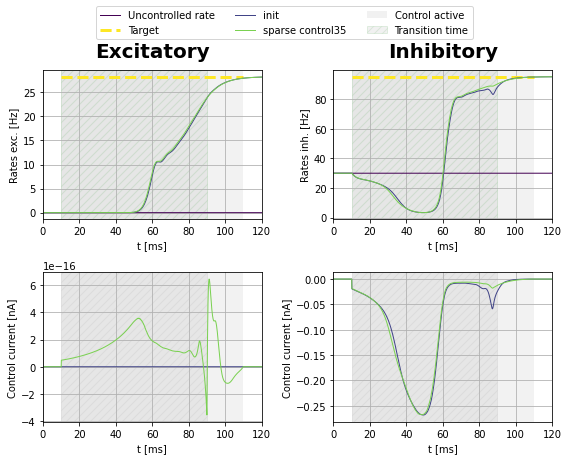

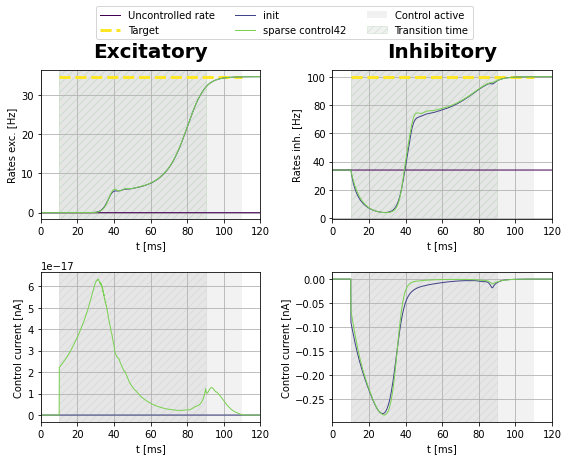

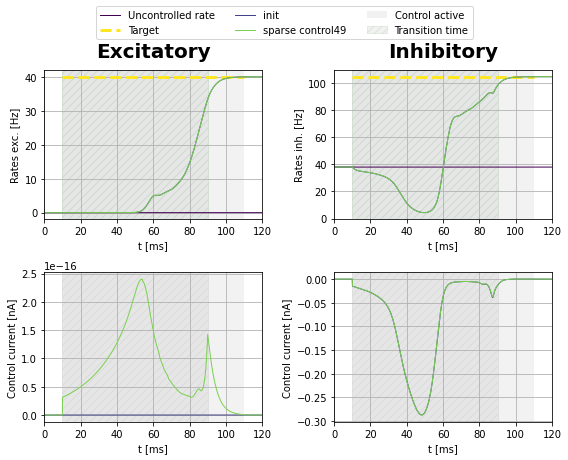

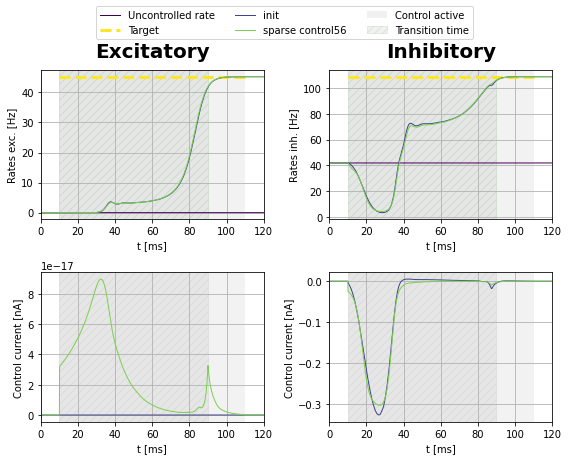

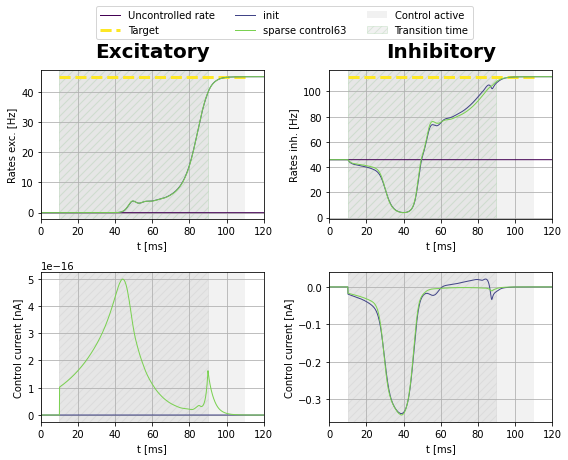

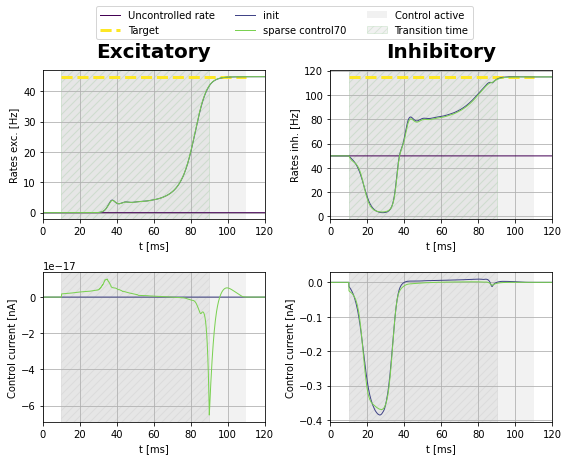

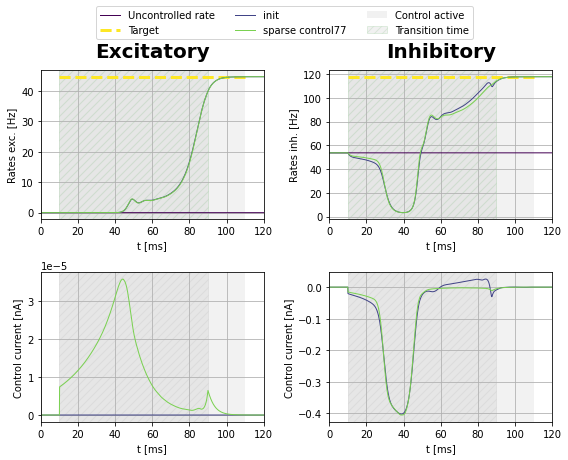

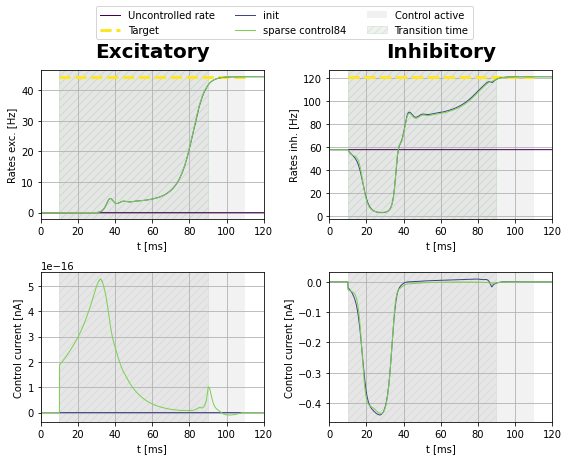

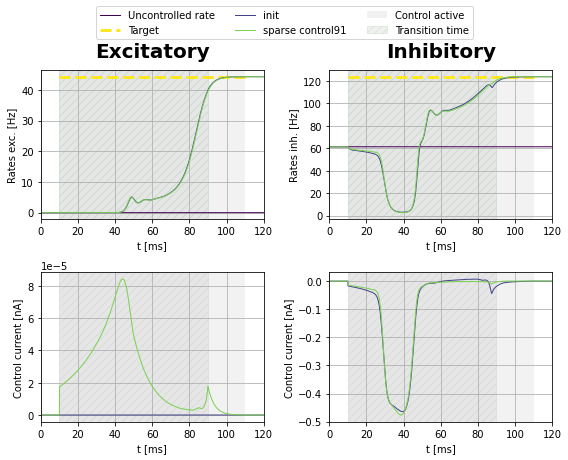

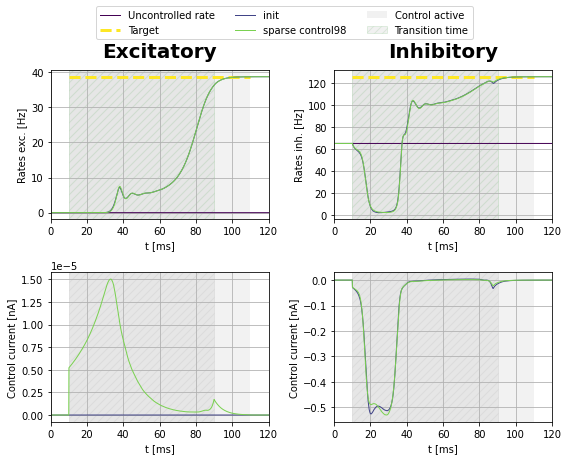

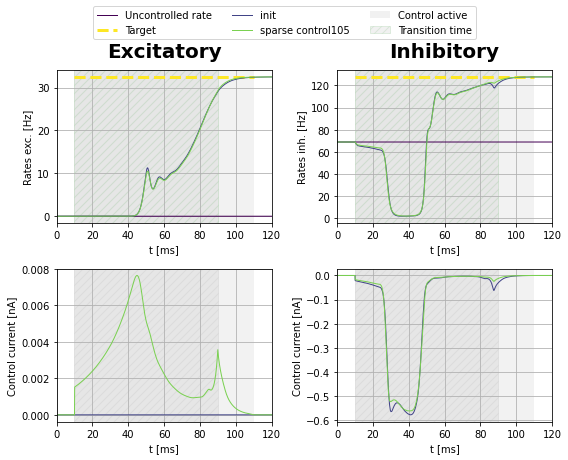

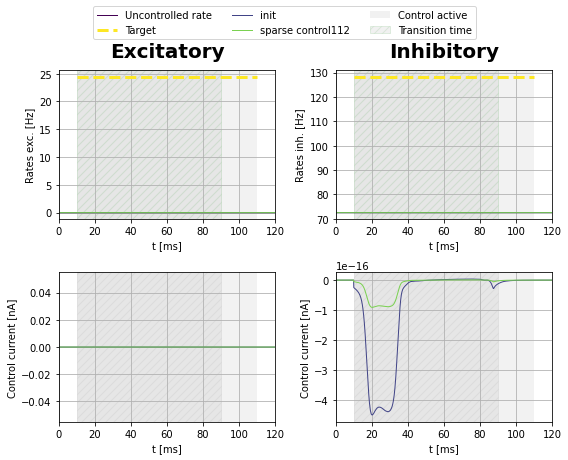

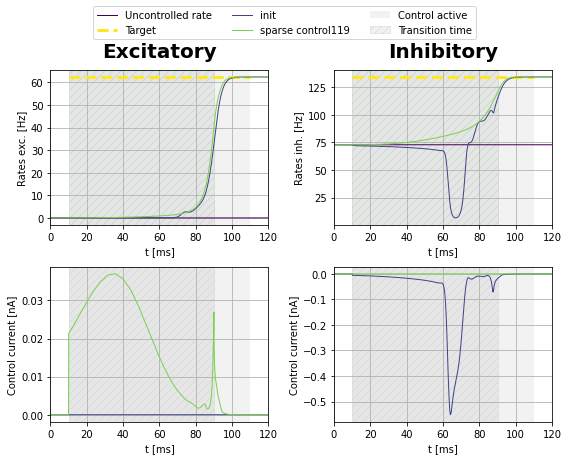

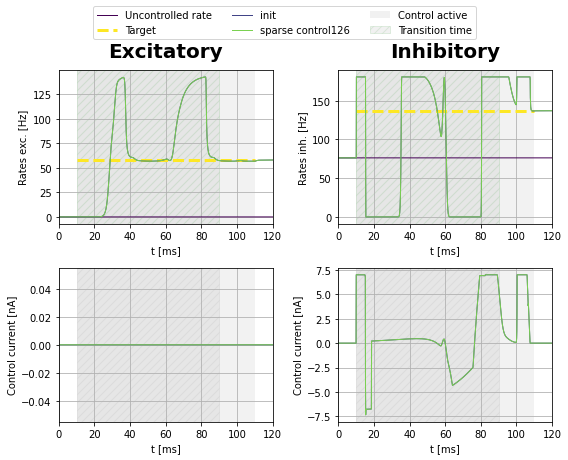

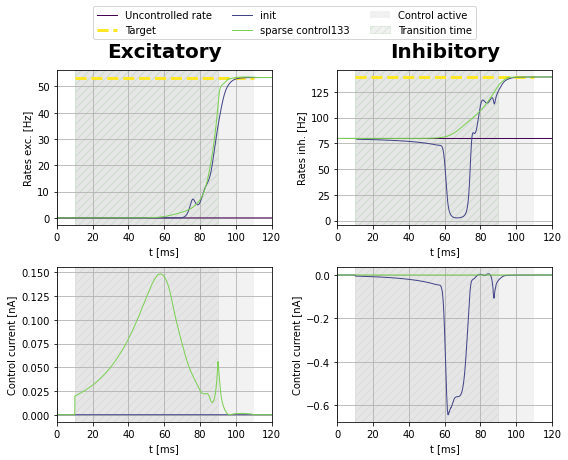

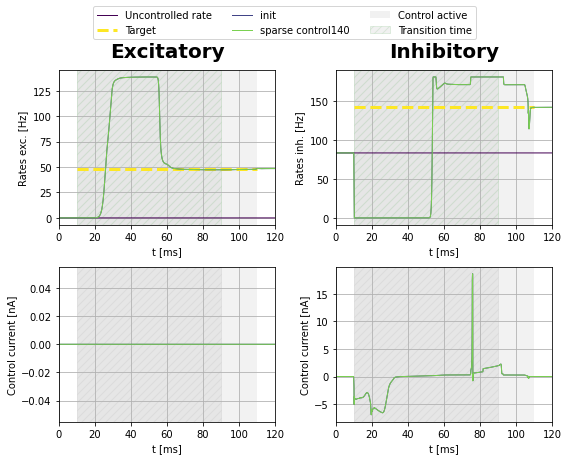

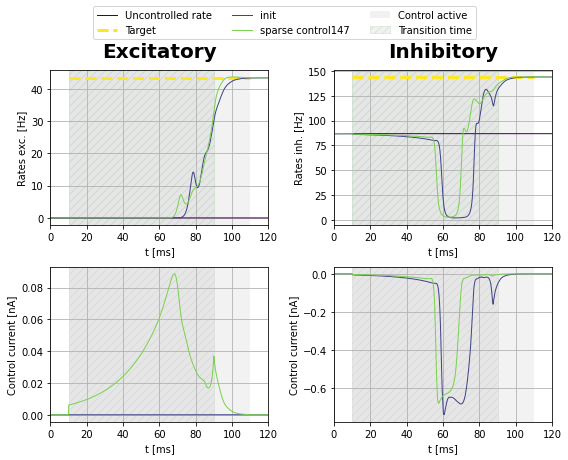

In [19]:
for i in i_range:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [20]:
factor_iteration = 20

for k in range(20):
    for i in i_range:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i])
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
weight =  5657.000561564565
set cost params:  1.0 0.0 5657.000561564565
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5883.643340883805
Gradient descend method:  None
RUN  1 , total integrated cost =  5883.624609339009
RUN  2 , total integrated cost =  5883.624282798133
RUN  3 , total integrated cost =  5883.624272010676
RUN  4 , total integrated cost =  5883.624271644749
RUN  5 , total integrated cost =  5883.624271630592
RUN  6 , total integrated cost =  5883.624271630195
RUN  7 , total integrated cost =  5883.6242716301895
RUN  8 , total integrated cost =  5883.624271630188
RUN  9 , total integrated cost =  5883.624271630182
RUN  10 , total integrated cost =  5883.62427163018
RUN  11 , total integrated cost =  5883.624271630179
State only changes marginally.


ERROR:root:Problem in initial value trasfer


RUN  12 , total integrated cost =  5883.624271630179
Control only changes marginally.
RUN  12 , total integrated cost =  5883.624271630179
Improved over  12  iterations in  2.2686625476926565  seconds by  0.0003241062131280614  percent.
Problem in initial value trasfer:  Vmean_exc -56.62600567986811 -56.62600725711751
-------  7 0.4000000000000001 0.3750000000000001
weight =  3147.5618730992546
set cost params:  1.0 0.0 3147.5618730992546
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5526.177450798157
Gradient descend method:  None
RUN  1 , total integrated cost =  5525.944372709978
RUN  2 , total integrated cost =  5525.935209834581
RUN  3 , total integrated cost =  5525.934041681905
RUN  4 , total integrated cost =  5525.933873514091
RUN  5 , total integrated cost =  5525.9338469948825
RUN  6 , total integrated cost =  5525.933845205487
RUN  7 , total integrated cost =  5525.933844949287
RUN  8 , total integrated cost =  5525.933844908423
RUN  9 , total inte

ERROR:root:Problem in initial value trasfer


RUN  15 , total integrated cost =  5525.933844901361
Control only changes marginally.
RUN  15 , total integrated cost =  5525.933844901361
Improved over  15  iterations in  2.7837029080837965  seconds by  0.004408217053565977  percent.
Problem in initial value trasfer:  Vmean_exc -56.62576967932038 -56.625753456563345
-------  14 0.4000000000000001 0.42500000000000016
weight =  1386.8446995961256
set cost params:  1.0 0.0 1386.8446995961256
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4638.437810483489
Gradient descend method:  None


...

RUN  1 , total integrated cost =  28473.1969310013
Control only changes marginally.
RUN  1 , total integrated cost =  28473.1969310013
Improved over  1  iterations in  0.20272506400942802  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70403556790496 -56.70403420229561
-------  140 0.5250000000000001 0.8750000000000006
weight =  188.44452406618763
set cost params:  1.0 0.0 188.44452406618763
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23408.417001584927
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  23408.417001584927
Control only changes marginally.
RUN  1 , total integrated cost =  23408.417001584927
Improved over  1  iterations in  0.5392467193305492  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.700801623474206 -56.70081485579882
-------  147 0.5000000000000002 0.9000000000000006
weight =  1494.2536903839468
set cost params:  1.0 0.0 1494.2536903839468
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18787.22085539535
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  18787.22085539535
Control only changes marginally.
RUN  1 , total integrated cost =  18787.22085539535
Improved over  1  iterations in  0.19419981725513935  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.692118210415344 -56.69211368907903


In [21]:
with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)